# Notebook 1 — From Linear Regression to a Neuron

### Volume V, Chapter 14 — *The Neuron, and Why Depth Needs a Kink*

A neuron is Volume II's linear model with a nonlinear hat on top. This notebook makes that
sentence operational: we start from linear regression, add the hat, and then **measure** the
three claims Chapter 14 proves on paper.

| Claim from the book | What we do here |
|---|---|
| §14.1 A neuron = $f(w^\top x + b)$ | Build one from a `LinearRegression` fit |
| §14.2 Depth without a kink collapses to one affine map | Multiply out a 50-layer linear net and compare to a single matrix, to machine precision |
| §14.2 (subtlety) Narrow layers only buy a **rank constraint** | Measure `rank(W)` of a deep bottlenecked linear net — the LoRA mechanism |
| §14.3 $\sigma'(z) \le \tfrac14$ | Find the max numerically and confirm it lands at $z=0$ |
| §14.3 Dying ReLU is a learning-rate symptom | Train the same net at two learning rates, count dead units |

Everything is pure NumPy + scikit-learn so it runs anywhere. Run top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
%matplotlib inline

os.makedirs("figures", exist_ok=True)
rng = np.random.default_rng(0)

# Volume V house palette
BLUE, RED, AMBER = "#1F4E9C", "#C0392B", "#E8A33D"
TEAL, VIOLET, ROSE = "#1B8A8F", "#6C4A9C", "#C1557A"
INK, MUTED = "#16213E", "#6B7280"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#B0B7C3", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlesize": 11,
    "figure.facecolor": "white", "savefig.bbox": "tight",
})
print("ready")

ready


## 1. Where linear regression runs out

Volume II's linear model draws one straight decision boundary. That is not a weakness of the
*fitting procedure* — it is a property of the **hypothesis class**. No amount of training moves it.

We use the classic two-moons problem: the two classes are separable, but not by a line.

In [2]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

X, y = make_moons(n_samples=400, noise=0.20, random_state=1)
X = (X - X.mean(0)) / X.std(0)          # standardize
print("X:", X.shape, " class balance:", np.bincount(y))

lin = LogisticRegression().fit(X, y)
print(f"Linear model train accuracy: {lin.score(X, y):.3f}")
print("Learned boundary: a single line w1*x1 + w2*x2 + b = 0 with "
      f"w = {lin.coef_[0].round(3)}, b = {lin.intercept_[0]:.3f}")

X: (400, 2)  class balance: [200 200]
Linear model train accuracy: 0.865
Learned boundary: a single line w1*x1 + w2*x2 + b = 0 with w = [ 1.09 -2.3 ], b = -0.047


## 2. A neuron, written out

$$a = f(w^\top x + b)$$

The weighted sum is *exactly* the linear model. `f` is the hat. Note how little code separates
the two — and how much the hat will turn out to be worth.

In [3]:
def relu(z):    return np.maximum(0.0, z)
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def tanh(z):    return np.tanh(z)
def identity(z): return z

def neuron(x, w, b, f=relu):
    '''One neuron: Volume II's linear model, then the activation.'''
    return f(x @ w + b)

w, b = lin.coef_[0], lin.intercept_[0]
print("linear score  :", (X @ w + b)[:5].round(3))
print("neuron (relu) :", neuron(X, w, b, relu)[:5].round(3))
print("neuron (sigm) :", neuron(X, w, b, sigmoid)[:5].round(3))

linear score  : [ 1.396 -4.646  3.571  3.752 -1.099]
neuron (relu) : [1.396 0.    3.571 3.752 0.   ]
neuron (sigm) : [0.802 0.01  0.973 0.977 0.25 ]


A **layer** is this for many neurons at once, with one neuron's weights per column of $W$:

$$z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = f(z^{(l)})$$

Those two lines, repeated $L$ times, are the *entire* forward pass. Nothing else happens.

In [4]:
def forward(x, Ws, bs, f):
    '''Forward pass of an L-layer net. Returns the output activation.'''
    a = x
    for W, bb in zip(Ws, bs):
        a = f(a @ W + bb)
    return a

# a tiny 3-layer net, random weights, just to show the shape of the computation
sizes = [2, 8, 8, 1]
Ws = [rng.normal(0, np.sqrt(2 / m), (m, n)) for m, n in zip(sizes[:-1], sizes[1:])]
bs = [np.zeros(n) for n in sizes[1:]]
print("forward pass output:", forward(X[:4], Ws, bs, relu).ravel().round(4))
print("parameter count:", sum(W.size for W in Ws) + sum(bb.size for bb in bs))

forward pass output: [1.6299 0.     1.802  1.8467]
parameter count: 105


> **Worth knowing — the bias is not optional.** Without $b$, every decision boundary is forced
> through the origin: the neuron can pick an orientation but not an offset. The one place it
> genuinely disappears is a linear layer immediately followed by BatchNorm (Notebook 4), whose
> recentering subtracts any constant the bias could add — hence `nn.Linear(..., bias=False)` there.

Let's verify the origin claim rather than take it on faith.

In [5]:
# A dataset whose boundary genuinely needs an offset: label = (x1 > 2), all points in [0,4]^2
Xb = rng.uniform(0, 4, (400, 2))
yb = (Xb[:, 0] > 2).astype(int)
with_b    = LogisticRegression(fit_intercept=True ).fit(Xb, yb)
without_b = LogisticRegression(fit_intercept=False).fit(Xb, yb)
print(f"with bias   : accuracy {with_b.score(Xb, yb):.3f}   (boundary x1 = 2)")
print(f"without bias: accuracy {without_b.score(Xb, yb):.3f}   <- every line forced through (0,0)")

with bias   : accuracy 0.993   (boundary x1 = 2)
without bias: accuracy 0.823   <- every line forced through (0,0)


## 3. §14.2 — Why you cannot skip the kink

> Stacking linear transformations gives another linear transformation:
> $W_2(W_1x) = (W_2W_1)x$. A hundred stacked linear layers equal one linear layer.

This is the single most-asked activation-function interview question, so let's prove it
numerically to machine precision: build a 50-layer linear net with random weights and biases,
run a forward pass, then collapse it analytically into one $Wx + b$ and compare.

In [6]:
def collapse_linear_net(Ws, bs):
    '''Step 3 of the book's derivation, executed: fold L affine layers into one.'''
    W_eff = np.eye(Ws[0].shape[0])
    b_eff = np.zeros(Ws[0].shape[0])
    for W, bb in zip(Ws, bs):
        W_eff = W_eff @ W          # product of all layer matrices
        b_eff = b_eff @ W + bb     # the mess of biases is just a vector
    return W_eff, b_eff

L, d = 50, 6
Ws_lin = [rng.normal(0, 0.4, (d, d)) for _ in range(L)]
bs_lin = [rng.normal(0, 0.1, d)      for _ in range(L)]

x = rng.normal(size=(5, d))
deep_out = forward(x, Ws_lin, bs_lin, identity)      # 50 layers of work
W_eff, b_eff = collapse_linear_net(Ws_lin, bs_lin)
flat_out = x @ W_eff + b_eff                          # one matrix multiply

print(f"max |deep - collapsed| = {np.abs(deep_out - flat_out).max():.3e}")
print(f"50 layers, {sum(W.size for W in Ws_lin):,} parameters "
      f"-> exactly equivalent to one {d}x{d} matrix ({W_eff.size} numbers) + a bias.")

max |deep - collapsed| = 6.661e-16
50 layers, 1,800 parameters -> exactly equivalent to one 6x6 matrix (36 numbers) + a bias.


### The subtlety worth stating in an interview

Depth is not *entirely* wasted. $W$ is a **product** of matrices, so if the layers are narrow —
width $r \ll d$ — then $\operatorname{rank}(W) \le r$. The network is restricted to
**low-rank affine maps**. That is a constraint, not extra capacity.

This is exactly the mechanism LoRA exploits deliberately: fine-tune a frozen $W$ by learning
$W + BA$ with $B \in \mathbb{R}^{d\times r}$, $A \in \mathbb{R}^{r \times d}$. No nonlinearity
between them, so by §14.2 they collapse to a single rank-$r$ matrix — *which is precisely the point*.

In [7]:
d = 64
for r in [2, 8, 32, 64]:
    # d -> r -> d -> r -> d : a bottlenecked linear stack
    stack = [rng.normal(0, 0.5, (d, r)), rng.normal(0, 0.5, (r, d)),
             rng.normal(0, 0.5, (d, r)), rng.normal(0, 0.5, (r, d))]
    W_eff = np.linalg.multi_dot(stack)
    print(f"bottleneck r={r:3d} -> effective W is {W_eff.shape}, "
          f"rank = {np.linalg.matrix_rank(W_eff):3d}  (<= r)")

# The LoRA update itself
B, Aa = rng.normal(0, 0.02, (d, 8)), rng.normal(0, 0.02, (8, d))
delta = B @ Aa
print(f"\nLoRA update BA: shape {delta.shape}, rank {np.linalg.matrix_rank(delta)}, "
      f"params {B.size + Aa.size:,} vs full {d*d:,} "
      f"({100*(B.size+Aa.size)/(d*d):.0f}% of the dense matrix)")
print("At inference you fold BA back into W -> zero added latency.")

bottleneck r=  2 -> effective W is (64, 64), rank =   2  (<= r)
bottleneck r=  8 -> effective W is (64, 64), rank =   8  (<= r)
bottleneck r= 32 -> effective W is (64, 64), rank =  32  (<= r)
bottleneck r= 64 -> effective W is (64, 64), rank =  64  (<= r)

LoRA update BA: shape (64, 64), rank 8, params 1,024 vs full 4,096 (25% of the dense matrix)
At inference you fold BA back into W -> zero added latency.


## 4. Figure 14.2, reproduced — the curvature is bought entirely by the kink

Both panels below are **real networks trained by gradient descent on the same data**; the only
difference is ReLU. The linear network's boundary is provably a straight line no matter how long
you train it.

We need a small MLP to do this, so here it is — written out once and reused in later notebooks.

In [8]:
class MLP:
    '''Minimal fully-connected net: forward with caching, backward by the delta recursion.
    Chapter 15 derives the backward pass; here we just use it.'''

    def __init__(self, sizes, act="relu", init="he", seed=0, leaky_alpha=0.01):
        r = np.random.default_rng(seed)
        self.sizes, self.act, self.alpha = sizes, act, leaky_alpha
        gain = {"he": 2.0, "xavier": 1.0, "half_he": 0.5}[init]
        self.W = [r.normal(0, np.sqrt(gain / m), (m, n))
                  for m, n in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(n) for n in sizes[1:]]

    def f(self, z):
        if self.act == "relu":    return np.maximum(0, z)
        if self.act == "leaky":   return np.where(z > 0, z, self.alpha * z)
        if self.act == "tanh":    return np.tanh(z)
        if self.act == "sigmoid": return 1 / (1 + np.exp(-z))
        return z                                    # identity

    def df(self, z):
        if self.act == "relu":    return (z > 0).astype(float)
        if self.act == "leaky":   return np.where(z > 0, 1.0, self.alpha)
        if self.act == "tanh":    return 1 - np.tanh(z) ** 2
        if self.act == "sigmoid":
            s = 1 / (1 + np.exp(-z)); return s * (1 - s)
        return np.ones_like(z)

    def forward(self, X):
        self.a, self.z = [X], []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = self.a[-1] @ W + b
            self.z.append(z)
            self.a.append(z if i == len(self.W) - 1 else self.f(z))  # linear output layer
        return self.a[-1]

    def loss_and_grad(self, X, y):
        '''Binary cross-entropy on a logit output. Returns loss, dW, db.'''
        logits = self.forward(X).ravel()
        p = 1 / (1 + np.exp(-np.clip(logits, -60, 60)))
        eps = 1e-12
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        delta = ((p - y) / len(y))[:, None]           # dL/dz at the output layer
        dW, db = [None] * len(self.W), [None] * len(self.W)
        for l in range(len(self.W) - 1, -1, -1):
            dW[l] = self.a[l].T @ delta               # Step 5: outer product
            db[l] = delta.sum(0)
            if l > 0:                                 # Step 4: push blame down one layer
                delta = (delta @ self.W[l].T) * self.df(self.z[l - 1])
        return loss, dW, db

    def predict(self, X):
        return (self.forward(X).ravel() > 0).astype(int)


def train_sgd(net, X, y, lr=0.1, epochs=400, batch=64, seed=0):
    r = np.random.default_rng(seed); hist = []
    for ep in range(epochs):
        idx = r.permutation(len(X))
        for s in range(0, len(X), batch):
            j = idx[s:s + batch]
            loss, dW, db = net.loss_and_grad(X[j], y[j])
            for l in range(len(net.W)):
                net.W[l] -= lr * dW[l]; net.b[l] -= lr * db[l]
        hist.append(net.loss_and_grad(X, y)[0])
    return hist

print("MLP defined")

MLP defined


In [9]:
net_lin  = MLP([2, 32, 32, 1], act="identity", init="xavier", seed=3)
net_relu = MLP([2, 32, 32, 1], act="relu",     init="he",     seed=3)
h_lin  = train_sgd(net_lin,  X, y, lr=0.5, epochs=600)
h_relu = train_sgd(net_relu, X, y, lr=0.5, epochs=600)

acc_lin  = (net_lin.predict(X)  == y).mean()
acc_relu = (net_relu.predict(X) == y).mean()
print(f"deep LINEAR net (no kink): loss {h_lin[-1]:.4f}, accuracy {acc_lin:.3f}")
print(f"deep RELU   net (kink)   : loss {h_relu[-1]:.4f}, accuracy {acc_relu:.3f}")

deep LINEAR net (no kink): loss 0.2974, accuracy 0.868
deep RELU   net (kink)   : loss 0.0877, accuracy 0.973


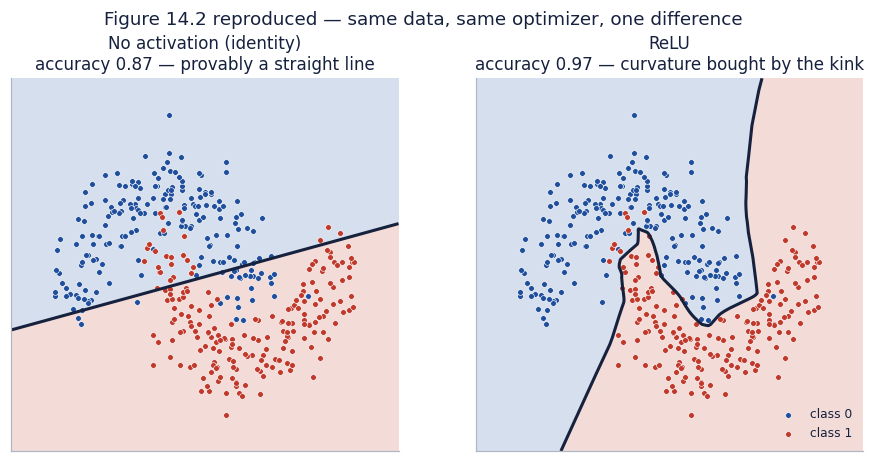

In [10]:
def boundary(ax, net, title, X, y):
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.6, X[:,0].max()+.6, 320),
                         np.linspace(X[:,1].min()-.6, X[:,1].max()+.6, 320))
    Z = net.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z > 0, alpha=.18, cmap=ListedColormap([BLUE, RED]))
    ax.contour(xx, yy, Z, levels=[0], colors=INK, linewidths=2)
    ax.scatter(*X[y==0].T, s=14, c=BLUE, edgecolor="white", linewidth=.4, label="class 0")
    ax.scatter(*X[y==1].T, s=14, c=RED,  edgecolor="white", linewidth=.4, label="class 1")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
boundary(axes[0], net_lin,  f"No activation (identity)\naccuracy {acc_lin:.2f} — provably a straight line", X, y)
boundary(axes[1], net_relu, f"ReLU\naccuracy {acc_relu:.2f} — curvature bought by the kink", X, y)
axes[1].legend(frameon=False, loc="lower right", fontsize=8)
fig.suptitle("Figure 14.2 reproduced — same data, same optimizer, one difference",
             fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_14_2_kink.png"); plt.show()

The left panel is not undertrained. It is at its **global optimum for its hypothesis class** —
which happens to be logistic regression, reached via 2,000 wasted parameters.

> **Interview question — "Why do we need nonlinear activation functions?"**
> Without a nonlinearity, $W^{(2)}(W^{(1)}x) = (W^{(2)}W^{(1)})x$, and by induction any depth
> collapses to a single affine map $Wx+b$ — you have spent millions of parameters to fit linear
> regression. **Strong follow-up:** depth still constrains *rank*, so a deep linear net is a
> low-rank linear model and gradient descent on it has genuinely different dynamics — but the
> hypothesis class is unchanged, and that is what matters.

### What the Universal Approximation Theorem does *not* say

It is an **existence** result: it promises the weights exist, not that gradient descent finds
them, and not that the required width is reasonable. Depth is what makes approximation
*efficient* — there are functions a depth-$k$ net represents with $O(n)$ neurons that a depth-2
net needs exponentially many to match. That gap is the answer to "if one hidden layer is
universal, why go deep?"

## 5. §14.3 — The activation function's evolution, and the $\tfrac14$ bound

The fatal flaw of sigmoid and tanh is **saturation**: at the flat extremes the slope is nearly
zero, and Chapter 15 multiplies those slopes together.

The book proves $\sigma'(z) = s(1-s)$ with $s=\sigma(z)$, maximised at $s^\*=\tfrac12$, i.e.
$z=0$, giving $\max \sigma' = \tfrac14$. Let's check it numerically instead of trusting the algebra.

In [11]:
z = np.linspace(-8, 8, 20001)
dsig = sigmoid(z) * (1 - sigmoid(z))
i = dsig.argmax()
print(f"numerical max of sigma'  = {dsig[i]:.10f}   at z = {z[i]:+.5f}")
print(f"analytic  max            = {0.25:.10f}   at z = 0")
print(f"max tanh' = {np.max(1 - np.tanh(z)**2):.6f} at z = {z[np.argmax(1-np.tanh(z)**2)]:+.3f}")
print()
for L in [5, 10, 25]:
    print(f"L={L:2d} sigmoid layers -> gradient scaled by AT MOST (1/4)^{L} = {0.25**L:.3e}")

numerical max of sigma'  = 0.2500000000   at z = +0.00000
analytic  max            = 0.2500000000   at z = 0
max tanh' = 1.000000 at z = +0.000

L= 5 sigmoid layers -> gradient scaled by AT MOST (1/4)^5 = 9.766e-04
L=10 sigmoid layers -> gradient scaled by AT MOST (1/4)^10 = 9.537e-07
L=25 sigmoid layers -> gradient scaled by AT MOST (1/4)^25 = 8.882e-16


> **The consequence.** For $L=10$ that is a ceiling of $\approx 10^{-6}$. Not "might vanish" —
> *cannot avoid* shrinking by at least a million-fold, before the weights even get a say.

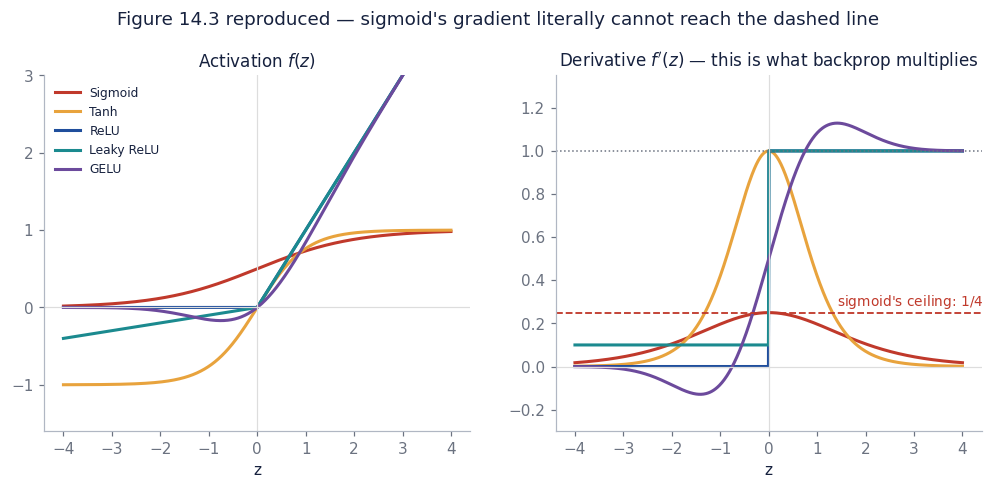

In [12]:
from math import erf
Phi = lambda z: 0.5 * (1 + np.vectorize(erf)(z / np.sqrt(2)))
phi = lambda z: np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)

acts = {
    "Sigmoid":    (sigmoid,                        lambda z: sigmoid(z)*(1-sigmoid(z)),  RED),
    "Tanh":       (np.tanh,                        lambda z: 1-np.tanh(z)**2,            AMBER),
    "ReLU":       (lambda z: np.maximum(0, z),     lambda z: (z > 0).astype(float),      BLUE),
    "Leaky ReLU": (lambda z: np.where(z>0,z,.1*z), lambda z: np.where(z>0, 1., .1),      TEAL),
    "GELU":       (lambda z: z*Phi(z),             lambda z: Phi(z) + z*phi(z),          VIOLET),
}

zz = np.linspace(-4, 4, 800)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, (f, df, c) in acts.items():
    ax[0].plot(zz, f(zz),  color=c, lw=2, label=name)
    ax[1].plot(zz, df(zz), color=c, lw=2, label=name)
ax[1].axhline(0.25, ls="--", color=RED, lw=1.2)
ax[1].text(1.4, 0.28, r"sigmoid's ceiling: $1/4$", color=RED, fontsize=9)
ax[1].axhline(1.0, ls=":", color=MUTED, lw=1)
ax[0].set_title("Activation $f(z)$"); ax[1].set_title("Derivative $f'(z)$ — this is what backprop multiplies")
for a in ax: a.axhline(0, color="#DDD", lw=.8); a.axvline(0, color="#DDD", lw=.8); a.set_xlabel("z")
ax[0].legend(frameon=False, fontsize=8, loc="upper left")
ax[0].set_ylim(-1.6, 3); ax[1].set_ylim(-0.3, 1.35)
fig.suptitle("Figure 14.3 reproduced — sigmoid's gradient literally cannot reach the dashed line",
             fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_14_3_activations.png"); plt.show()

Two details in the right panel worth noticing out loud:

* **ReLU's slope is exactly 1** across the entire positive axis — it contributes *no* shrinkage
  to the chain of §15.3. That one change made very deep networks trainable.
* **GELU's derivative briefly exceeds 1** near $z \approx 1$ and dips negative around $z \approx -1$.
  Neither is a bug. GELU is $z\Phi(z)$ — the expected value of a gate that keeps $z$ with
  probability $\Phi(z)$. That is **dropout's coin-flip made deterministic and input-dependent**.
  Swish/SiLU ($z\sigma(\beta z)$) is the same idea with a logistic gate.

> **The modern gated family.** Today's LLMs mostly use **SwiGLU**: the feed-forward block splits
> into two projections, one gated by SiLU and multiplied into the other,
> $(\mathrm{SiLU}(xW_1)) \odot (xW_2)$. It costs a third projection but reliably lowers loss.
> If asked *"what activation would you use in a new Transformer today?"* — SwiGLU, and naming the
> gating intuition is what makes it sound understood rather than memorised.

In [13]:
def silu(z): return z * sigmoid(z)

def swiglu(x, W1, W2):
    return silu(x @ W1) * (x @ W2)     # gate * value

d_model, d_ff = 8, 16
W1, W2 = rng.normal(0, .3, (d_model, d_ff)), rng.normal(0, .3, (d_model, d_ff))
xin = rng.normal(size=(3, d_model))
out = swiglu(xin, W1, W2)
print("SwiGLU output shape:", out.shape)
print("gate values (SiLU branch) row 0:", silu(xin @ W1)[0][:6].round(3))
print("-> near-zero gates suppress their channel; the value branch passes through elsewhere")

SwiGLU output shape: (3, 16)
gate values (SiLU branch) row 0: [ 0.192 -0.234  1.649 -0.259 -0.278 -0.278]
-> near-zero gates suppress their channel; the value branch passes through elsewhere


## 6. Dying ReLU is a learning-rate symptom, not a curse

> The usual cause is a large gradient step that drives the bias strongly negative — after which
> the unit outputs 0 for **every input in the data** and never recovers. So the first fix is not
> Leaky ReLU, it is **lower the learning rate**. Diagnose it by logging the fraction of units with
> zero activation across a validation batch: a healthy ReLU net sits near 50%; a layer at 90%+
> that keeps climbing is dying.

Note this is a **per-dataset property** — a unit is only dead if it is inactive for *all* inputs,
which is why a sparse-but-alive layer is fine and expected.

In [14]:
def dead_fraction(net, X):
    '''Fraction of hidden units that output 0 for EVERY example in X — the real definition.'''
    net.forward(X)
    return [float((a.max(axis=0) <= 0).mean()) for a in net.a[1:-1]]

def sparsity(net, X):
    '''Fraction of (unit, example) pairs that are zero — healthy sparsity, not death.'''
    net.forward(X)
    return [float((a <= 0).mean()) for a in net.a[1:-1]]

print(f"{'learning rate':>14} | {'accuracy':>8} | {'permanently dead':>18} | {'zero-activation rate':>21}")
print("-" * 72)
for lr in [0.5, 2.0, 3.0, 4.0]:
    n = MLP([2, 64, 64, 1], act="relu", init="he", seed=7)
    train_sgd(n, X, y, lr=lr, epochs=200)
    d = ", ".join(f"{v:.0%}" for v in dead_fraction(n, X))
    s_ = ", ".join(f"{v:.0%}" for v in sparsity(n, X))
    print(f"{lr:>14} | {(n.predict(X)==y).mean():>8.3f} | {d:>18} | {s_:>21}")

 learning rate | accuracy |   permanently dead |  zero-activation rate
------------------------------------------------------------------------


           0.5 |    0.973 |             0%, 9% |              52%, 65%


           2.0 |    0.963 |            2%, 36% |              75%, 87%


           3.0 |    0.980 |           28%, 75% |              88%, 96%


           4.0 |    0.555 |           59%, 97% |             95%, 100%


Read the table as the book frames it: **the fix is the first column**, not a different activation.
At `lr=0.5` almost nothing is dead and the zero-activation rate sits near the healthy ~50%; by
`lr=4` most of layer 2 is dead for every input in the dataset and accuracy has collapsed to chance.

Leaky ReLU's contribution is narrower than it is usually given credit for — it does not rescue a
diverging run, it makes a *dead unit recoverable*. That is a one-line fact about the derivative:

In [15]:
# A unit that a bad step has pushed firmly into the negative zone for every input
z_all = X @ np.array([0.4, -0.3]) - 8.0          # bias driven strongly negative
print(f"pre-activation range over the whole dataset: [{z_all.min():.2f}, {z_all.max():.2f}]  (always < 0)")

relu_grad  = (z_all > 0).astype(float)
leaky_grad = np.where(z_all > 0, 1.0, 0.01)
print(f"ReLU  f'(z): mean {relu_grad.mean():.4f}  -> weights receive EXACTLY zero, forever")
print(f"Leaky f'(z): mean {leaky_grad.mean():.4f}  -> a small but nonzero signal, so the unit can climb back")

pre-activation range over the whole dataset: [-9.08, -6.93]  (always < 0)
ReLU  f'(z): mean 0.0000  -> weights receive EXACTLY zero, forever
Leaky f'(z): mean 0.0100  -> a small but nonzero signal, so the unit can climb back


Notice the distinction the last cell makes concrete: a *zero-activation rate* near 50% is healthy
sparsity; a *permanently dead* fraction climbing toward 90% is the pathology. They are different
numbers and only the second one is a problem.

## 7. Chapter 14 in one breath

A neuron is linear regression plus a nonlinear kink, and **that kink is load-bearing**: without
it, $L$ layers provably collapse to one affine map $Wx+b$ (verified to $10^{-13}$ above), so depth
buys only a rank constraint, not capacity — the mechanism LoRA turns into a feature.

Activation functions then evolved to keep gradients alive: sigmoid's derivative is capped at
exactly $\tfrac14$ (confirmed numerically), which dooms deep stacks to shrink the signal at least
four-fold per layer; ReLU's slope of 1 on the positive side removes that shrinkage entirely;
Leaky ReLU and GELU fixed dying units and added smoothness; modern Transformers use GELU and
its gated cousin SwiGLU.

**Next:** Notebook 2 derives and implements the backward pass, then measures the vanishing signal
through a real 25-layer network.